# Model Comparison — Telecom Customer Churn

This notebook establishes the model-comparison workflow.

Objectives:
- Reuse the production data-preparation code in src/
- Reuse the stratified train/test split
- Reuse the leakage-safe preprocessing pipeline
- Evaluate candidate models using stratified out-of-fold predictions
- Evaluate the final candidate on the held-out test set
- Verify that the comparison framework reproduces the existing
  Logistic Regression baseline before introducing additional models

In [3]:
from pathlib import Path
import sys
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.preprocessing import (
    build_preprocessor,
    load_raw_data,
    prepare_dataset,
)
from src.data.split import create_train_test_split
from src.modeling.comparison import (
    evaluate_model_cv,
    fit_and_evaluate_test,
)

In [ ]:
df = load_raw_data()

X, y = prepare_dataset(df)

X_train, X_test, y_train, y_test = create_train_test_split(
    X,
    y,
)

print(f'Training rows: {len(X_train)}')
print(f'Test rows: {len(X_test)}')
print(f'Training churn rate: {y_train.mean():.6f}')
print(f'Test churn rate: {y_test.mean():.6f}')

Training rows: 6762
Test rows: 1691
Training churn rate: 0.064922
Test churn rate: 0.065050


In [5]:
logistic_regression = Pipeline(
    steps=[
        ('preprocessor', build_preprocessor(scale_numeric=True)),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ])

In [ ]:
logistic_cv_result = evaluate_model_cv(
    model=logistic_regression,
    X=X_train,
    y=y_train
)

logistic_cv_result['metrics']

{'PR-AUC': 0.08264539890467607, 'ROC-AUC': 0.5671707981527467}

In [ ]:
logistic_test_result = fit_and_evaluate_test(
    model=logistic_regression,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    threshold=0.06
)

logistic_test_result['metrics']

Threshold              0.060000
PR-AUC                 0.082143
ROC-AUC                0.559192
Precision              0.070406
Recall                 0.536364
F1                     0.124473
Customers Flagged    838.000000
Coverage               0.495565
dtype: float64

In [ ]:
comparison = pd.DataFrame(
    {
        'Logistic Regression': logistic_test_result['metrics']
    }
).T

comparison

,Threshold,PR-AUC,ROC-AUC,Precision,Recall,F1,Customers Flagged,Coverage
Logistic Regression,0.06,0.082143,0.559192,0.070406,0.536364,0.124473,838.0,0.495565


In [10]:
from sklearn.ensemble import RandomForestClassifier

In [12]:
random_forest = Pipeline(
    steps=[
        ('preprocessor', build_preprocessor(scale_numeric=False)),
        ('classifier', RandomForestClassifier(
                n_estimators=300,
                max_depth=None,
                min_samples_leaf=5,
                class_weight='balanced',
                random_state=42,
                n_jobs=-1
            ))
    ]
)

In [ ]:
random_forest_cv_result = evaluate_model_cv(
    model=random_forest,
    X=X_train,
    y=y_train,
)

random_forest_cv_result['metrics']

{'PR-AUC': 0.0806682669996597, 'ROC-AUC': 0.5618054922604211}

In [ ]:
random_forest_test_result = fit_and_evaluate_test(
    model=random_forest,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    threshold=0.06,
)

random_forest_test_result['metrics']

Threshold               0.060000
PR-AUC                  0.083352
ROC-AUC                 0.566592
Precision               0.065050
Recall                  1.000000
F1                      0.122154
Customers Flagged    1691.000000
Coverage                1.000000
dtype: float64

In [ ]:
comparison = pd.DataFrame(
    {
        'Logistic Regression': logistic_test_result['metrics'],
        'Random Forest': random_forest_test_result['metrics'],
    }
).T

comparison

,Threshold,PR-AUC,ROC-AUC,Precision,Recall,F1,Customers Flagged,Coverage
Logistic Regression,0.06,0.082143,0.559192,0.070406,0.536364,0.124473,838.0,0.495565
Random Forest,0.06,0.083352,0.566592,0.065050,1.000000,0.122154,1691.0,1.000000


In [ ]:
rf_proba = random_forest_test_result['test_probabilities']

pd.Series(rf_proba).describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

count    1691.000000
mean        0.395386
std         0.118971
min         0.123477
1%          0.175563
5%          0.217697
10%         0.248615
25%         0.302554
50%         0.386784
75%         0.475490
90%         0.554441
95%         0.605230
99%         0.697157
max         0.802524
dtype: float64

In [ ]:
print(f'Minimum probability: {rf_proba.min():.6f}')
print(f'Maximum probability: {rf_proba.max():.6f}')
print(f'Probability >= 0.06: {(rf_proba >= 0.06).mean():.6f}')

Minimum probability: 0.123477
Maximum probability: 0.802524
Probability >= 0.06: 1.000000


In [ ]:
comparison['Threshold'] = comparison['Threshold'].astype(float)
comparison

,Threshold,PR-AUC,ROC-AUC,Precision,Recall,F1,Customers Flagged,Coverage
Logistic Regression,0.06,0.082143,0.559192,0.070406,0.536364,0.124473,838.0,0.495565
Random Forest,0.06,0.083352,0.566592,0.065050,1.000000,0.122154,1691.0,1.000000


> The 0.06 threshold was established during Logistic Regression
> validation. It is shown here for reference and is not assumed to
> be an appropriate production threshold for Random Forest.
> Model ranking is therefore based primarily on threshold-independent
> probability metrics such as PR-AUC and ROC-AUC at this stage.

In [ ]:
from src.modeling.thresholds import evaluate_thresholds

rf_oof_proba = random_forest_cv_result['oof_predictions']

rf_threshold_results = evaluate_thresholds(
    y_true=y_train,
    y_proba=rf_oof_proba,
    thresholds=[
        0.05,
        0.10,
        0.15,
        0.20,
        0.25,
        0.30,
        0.35,
        0.40,
        0.45,
        0.50,
        0.55,
        0.60,
    ],
)

rf_threshold_results.sort_values(
    'F1',
    ascending=False,
)

,Threshold,Customers Flagged,Coverage,Precision,Recall,F1
6,0.35,3949,0.583999,0.077235,0.694761,0.139015
7,0.40,2988,0.441881,0.077309,0.526196,0.134812
8,0.45,2078,0.307306,0.079403,0.375854,0.131108
9,0.50,1291,0.190920,0.085980,0.252847,0.128324
5,0.30,5021,0.742532,0.069508,0.794989,0.127839
4,0.25,6112,0.903875,0.065772,0.915718,0.122729
3,0.20,6602,0.976338,0.065283,0.981777,0.122426
0,0.05,6762,1.000000,0.064922,1.000000,0.121928
1,0.10,6762,1.000000,0.064922,1.000000,0.121928
2,0.15,6746,0.997634,0.064927,0.997722,0.121921


In [ ]:
rf_test_at_035 = fit_and_evaluate_test(
    model=random_forest,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    threshold=0.35,
)

rf_test_at_035['metrics']

Threshold               0.350000
PR-AUC                  0.083352
ROC-AUC                 0.566592
Precision               0.076550
Recall                  0.718182
F1                      0.138354
Customers Flagged    1032.000000
Coverage                0.610290
dtype: float64

In [ ]:
comparison_thresholded = pd.DataFrame(
    {
        'Logistic Regression': logistic_test_result['metrics'],
        'Random Forest': rf_test_at_035['metrics'],
    }
).T

comparison_thresholded

,Threshold,PR-AUC,ROC-AUC,Precision,Recall,F1,Customers Flagged,Coverage
Logistic Regression,0.06,0.082143,0.559192,0.070406,0.536364,0.124473,838.0,0.495565
Random Forest,0.35,0.083352,0.566592,0.076550,0.718182,0.138354,1032.0,0.610290


In [22]:
from sklearn.ensemble import HistGradientBoostingClassifier

In [23]:
hist_gradient_boosting = Pipeline(
    steps=[
        ('preprocessor', build_preprocessor(scale_numeric=True)),

        ('classifier', 
        HistGradientBoostingClassifier(
            max_iter=1000,
            learning_rate=0.05,
            max_leaf_nodes=15,
            min_samples_leaf=20,
            l2_regularization=1.0,
            random_state=42
        ))
    ])

In [ ]:
hist_gb_cv_result = evaluate_model_cv(
    model=hist_gradient_boosting,
    X=X_train,
    y=y_train,
)

hist_gb_cv_result['metrics']

{'PR-AUC': 0.07964467864672728, 'ROC-AUC': 0.5389886220065805}

In [25]:
hist_gb_oof_proba = hist_gb_cv_result['oof_predictions']

pd.Series(hist_gb_oof_proba).describe(
    percentiles=[
        0.01,
        0.05,
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99,
    ]
)

count    6762.000000
mean        0.059730
std         0.084859
min         0.000058
1%          0.000598
5%          0.002844
10%         0.005367
25%         0.013158
50%         0.031511
75%         0.070692
90%         0.142812
95%         0.208367
99%         0.446305
max         0.913269
dtype: float64

In [ ]:
hist_gb_threshold_results = evaluate_thresholds(
    y_true=y_train,
    y_proba=hist_gb_oof_proba,
    thresholds=[
        0.05,
        0.10,
        0.15,
        0.20,
        0.25,
        0.30,
        0.35,
        0.40,
        0.45,
        0.50,
        0.55,
        0.60,
    ],
)

hist_gb_threshold_results.sort_values(
    'F1',
    ascending=False,
)

,Threshold,Customers Flagged,Coverage,Precision,Recall,F1
0,0.05,2367,0.350044,0.076468,0.412301,0.129009
1,0.10,1136,0.167998,0.083627,0.216401,0.120635
2,0.15,616,0.091097,0.095779,0.134396,0.111848
3,0.20,367,0.054274,0.106267,0.088838,0.096774
4,0.25,248,0.036676,0.104839,0.059226,0.075691
5,0.30,170,0.025140,0.117647,0.045558,0.065681
6,0.35,121,0.017894,0.115702,0.031891,0.050000
7,0.40,90,0.013310,0.133333,0.027335,0.045369
8,0.45,66,0.009760,0.166667,0.025057,0.043564
9,0.50,48,0.007098,0.187500,0.020501,0.036961


### HistGradientBoosting baseline

The initial HistGradientBoosting configuration produced lower OOF
PR-AUC and ROC-AUC than the Logistic Regression and Random Forest
baselines. Its probability distribution also differs substantially
from the other models, so thresholds are model-specific.

The threshold grid produced a maximum observed OOF F1 of 0.129009
at threshold 0.05. This threshold is treated as a validation
diagnostic and is not yet a production decision.

In [ ]:
cv_comparison = pd.DataFrame(
    {
        'Logistic Regression': logistic_cv_result['metrics'],
        'Random Forest': random_forest_cv_result['metrics'],
        'HistGradientBoosting': hist_gb_cv_result['metrics'],
    }
).T

cv_comparison.sort_values(
    'PR-AUC',
    ascending=False,
)

,PR-AUC,ROC-AUC
Logistic Regression,0.082645,0.567171
Random Forest,0.080668,0.561805
HistGradientBoosting,0.079645,0.538989


In [ ]:
model_summary = pd.DataFrame(
    [
        {
            'Model': 'Logistic Regression',
            'Model Type': 'Linear',
            'Scaling': True,
            'Class Weight': 'None',
        },
        {
            'Model': 'Random Forest',
            'Model Type': 'Bagging / Trees',
            'Scaling': False,
            'Class Weight': 'Balanced',
        },
        {
            'Model': 'HistGradientBoosting',
            'Model Type': 'Gradient Boosting / Trees',
            'Scaling': False,
            'Class Weight': 'None',
        },
    ]
)

model_summary

,Model,Model Type,Scaling,Class Weight
0,Logistic Regression,Linear,True,None
1,Random Forest,Bagging / Trees,False,Balanced
2,HistGradientBoosting,Gradient Boosting / Trees,False,None


In [ ]:
from src.modeling.tuning import tune_model

logistic_regression = Pipeline(
    steps=[
        ('preprocessor', build_preprocessor(scale_numeric=True)),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ]
)

logistic_param_grid = {
    'classifier__C': [0.01, 0.1, 1.0, 10.0, 100.0],
}

logistic_search = tune_model(model=logistic_regression, param_grid=logistic_param_grid, X_train=X_train, y_train=y_train)

print('Best Logistic Regression parameters:')
print(logistic_search.best_params_)
print()
print('Best CV PR-AUC:')
print(logistic_search.best_score_)

Best Logistic Regression parameters:
{'classifier__C': 0.01}

Best CV PR-AUC:
0.09232340660582934


In [ ]:
random_forest = Pipeline(
    steps=[
        ('preprocessor', build_preprocessor(scale_numeric=False)),
        ('classifier', RandomForestClassifier(
            class_weight='balanced',
            random_state=42,
            n_jobs=-1,
        )),
    ]
)

random_forest_param_grid = {
    'classifier__n_estimators': [200, 500],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_leaf': [2, 5, 10]
}

random_forest_search = tune_model(
    model=random_forest,
    param_grid=random_forest_param_grid,
    X_train=X_train,
    y_train=y_train,
)

print('Best Random Forest parameters:')
print(random_forest_search.best_params_)
print()
print('Best CV PR-AUC:')
print(random_forest_search.best_score_)

Best Random Forest parameters:
{'classifier__max_depth': 10, 'classifier__min_samples_leaf': 10, 'classifier__n_estimators': 500}

Best CV PR-AUC:
0.0954449104071666


In [ ]:
tuned_cv_comparison = pd.DataFrame([
    {
        'Model': 'Logistic Regression Tuned',
        'CV PR-AUC': logistic_search.best_score_,
        'Best Parameters': logistic_search.best_params_,
    },
    {
        'Model': 'Random Forest Tuned',
        'CV PR-AUC': random_forest_search.best_score_,
        'Best Parameters': random_forest_search.best_params_,
    },
])

tuned_cv_comparison

,Model,CV PR-AUC,Best Parameters
0,Logistic Regression Tuned,0.092323,{'classifier__C': 0.01}
1,Random Forest Tuned,0.095445,"{'classifier__max_depth': 10, 'classifier__min..."


In [ ]:
tuned_logistic_test = fit_and_evaluate_test(
    model=logistic_search.best_estimator_,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    threshold=0.06,
)

tuned_logistic_test['metrics']

Threshold              0.060000
PR-AUC                 0.079787
ROC-AUC                0.557789
Precision              0.073200
Recall                 0.563636
F1                     0.129572
Customers Flagged    847.000000
Coverage               0.500887
dtype: float64

In [ ]:
tuned_random_forest_test = fit_and_evaluate_test(
    model=random_forest_search.best_estimator_,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    threshold=0.35,
)

tuned_random_forest_test['metrics']

Threshold               0.350000
PR-AUC                  0.082791
ROC-AUC                 0.563366
Precision               0.066710
Recall                  0.927273
F1                      0.124466
Customers Flagged    1529.000000
Coverage                0.904199
dtype: float64

In [ ]:
tuned_test_comparison = pd.DataFrame([
    {
        'Model': 'Logistic Regression Tuned',
        **tuned_logistic_test['metrics'].to_dict(),
    },
    {
        'Model': 'Random Forest Tuned',
        **tuned_random_forest_test['metrics'].to_dict(),
    },
])

tuned_test_comparison

,Model,Threshold,PR-AUC,ROC-AUC,Precision,Recall,F1,Customers Flagged,Coverage
0,Logistic Regression Tuned,0.06,0.079787,0.557789,0.07320,0.563636,0.129572,847.0,0.500887
1,Random Forest Tuned,0.35,0.082791,0.563366,0.06671,0.927273,0.124466,1529.0,0.904199


In [ ]:
hist_gradient_boosting_test = fit_and_evaluate_test(
    model=hist_gradient_boosting,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    threshold=0.05,
)

hist_gradient_boosting_test['metrics']

Threshold              0.050000
PR-AUC                 0.089013
ROC-AUC                0.592640
Precision              0.092166
Recall                 0.545455
F1                     0.157687
Customers Flagged    651.000000
Coverage               0.384979
dtype: float64

In [44]:
hist_gradient_boosting_tuned = Pipeline(
    steps=[
        ("preprocessor", build_preprocessor(scale_numeric=False)),
        ("classifier", HistGradientBoostingClassifier(
            random_state=42,
        )),
    ]
)

hist_gradient_boosting_param_grid = {
    "classifier__max_iter": [200, 300],
    "classifier__learning_rate": [0.03, 0.05, 0.1],
    "classifier__max_leaf_nodes": [7, 15, 31],
    "classifier__min_samples_leaf": [10, 20, 50],
    "classifier__l2_regularization": [0.0, 1.0],
}

In [ ]:
hist_gradient_boosting_search = tune_model(
    model=hist_gradient_boosting_tuned,
    param_grid=hist_gradient_boosting_param_grid,
    X_train=X_train,
    y_train=y_train,
)

print("Best HistGradientBoosting parameters:")
print(hist_gradient_boosting_search.best_params_)

print()
print("Best CV PR-AUC:")
print(hist_gradient_boosting_search.best_score_)

Best HistGradientBoosting parameters:
{'classifier__l2_regularization': 1.0, 'classifier__learning_rate': 0.03, 'classifier__max_iter': 300, 'classifier__max_leaf_nodes': 7, 'classifier__min_samples_leaf': 50}

Best CV PR-AUC:
0.0918992813806306


In [47]:
hgb_tuned_test = fit_and_evaluate_test(
    model=hist_gradient_boosting_tuned,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    threshold=0.05,
)

hgb_tuned_test['metrics']

Threshold              0.050000
PR-AUC                 0.087748
ROC-AUC                0.581634
Precision              0.079019
Recall                 0.527273
F1                     0.137441
Customers Flagged    734.000000
Coverage               0.434063
dtype: float64

In [46]:
hgb_cv_results = (
    pd.DataFrame(hist_gradient_boosting_search.cv_results_)
    .sort_values("rank_test_score")
)

hgb_cv_results[
    [
        "rank_test_score",
        "mean_test_score",
        "std_test_score",
        "param_classifier__max_iter",
        "param_classifier__learning_rate",
        "param_classifier__max_leaf_nodes",
        "param_classifier__min_samples_leaf",
        "param_classifier__l2_regularization",
    ]
].head(10)

,rank_test_score,mean_test_score,std_test_score,param_classifier__max_iter,param_classifier__learning_rate,param_classifier__max_leaf_nodes,param_classifier__min_samples_leaf,param_classifier__l2_regularization
65,1,0.091899,0.007572,300,0.03,7,50,1.0
74,2,0.091593,0.006511,200,0.05,7,50,1.0
56,3,0.091573,0.010073,200,0.03,7,50,1.0
11,4,0.091433,0.006295,300,0.03,7,50,0.0
5,5,0.090571,0.005001,200,0.03,15,50,0.0
2,6,0.090272,0.008395,200,0.03,7,50,0.0
20,7,0.090080,0.007130,200,0.05,7,50,0.0
29,8,0.089983,0.006725,300,0.05,7,50,0.0
83,9,0.089920,0.005083,300,0.05,7,50,1.0
84,10,0.089247,0.012023,300,0.05,15,10,1.0


In [58]:
hist_gradient_boosting_cv = evaluate_model_cv(
    model=hist_gradient_boosting,
    X=X_train,
    y=y_train,
)

hist_gradient_boosting_cv["metrics"]

{'PR-AUC': 0.07964467864672728, 'ROC-AUC': 0.5389886220065805}

In [70]:
def build_model_comparison_row(
    model_name: str,
    cv_metrics: dict,
    test_metrics: pd.Series | None = None,
    cv_roc_auc: bool = True,
) -> dict:
    row = {
        "Model": model_name,
        "CV PR-AUC": cv_metrics.get("PR-AUC"),
        "CV ROC-AUC": cv_metrics.get("ROC-AUC") if cv_roc_auc else None,
        "Threshold": None,
        "Test PR-AUC": None,
        "Test ROC-AUC": None,
        "Test F1": None,
        "Test Recall": None,
        "Test Precision": None,
        "Coverage": None,
    }

    if test_metrics is not None:
        row.update({
            "Threshold": test_metrics["Threshold"],
            "Test PR-AUC": test_metrics["PR-AUC"],
            "Test ROC-AUC": test_metrics["ROC-AUC"],
            "Test F1": test_metrics["F1"],
            "Test Recall": test_metrics["Recall"],
            "Test Precision": test_metrics["Precision"],
            "Coverage": test_metrics["Coverage"],
        })

    return row

In [71]:
final_model_comparison = pd.DataFrame([

    build_model_comparison_row(
        "Logistic Regression",
        logistic_cv_result["metrics"],
        logistic_test_result["metrics"],
    ),

    build_model_comparison_row(
        "Random Forest",
        random_forest_cv_result["metrics"],
        random_forest_test_result["metrics"],
    ),

    build_model_comparison_row(
        "HistGradientBoosting",
        hist_gradient_boosting_cv["metrics"],
        hist_gradient_boosting_test["metrics"],
    ),

    build_model_comparison_row(
        "Logistic Regression Tuned",
        {"PR-AUC": logistic_search.best_score_},
        tuned_logistic_test["metrics"],
        cv_roc_auc=False,
    ),

    build_model_comparison_row(
        "Random Forest Tuned",
        {"PR-AUC": random_forest_search.best_score_},
        tuned_random_forest_test["metrics"],
        cv_roc_auc=False,
    ),

    build_model_comparison_row(
        "HistGradientBoosting Tuned",
        {"PR-AUC": hist_gradient_boosting_search.best_score_},
        hgb_tuned_test["metrics"],
        cv_roc_auc=False,
    ),
])

final_model_comparison

,Model,CV PR-AUC,CV ROC-AUC,Threshold,Test PR-AUC,Test ROC-AUC,Test F1,Test Recall,Test Precision,Coverage
0,Logistic Regression,0.082645,0.567171,0.06,0.082143,0.559192,0.124473,0.536364,0.070406,0.495565
1,Random Forest,0.080668,0.561805,0.06,0.083352,0.566592,0.122154,1.000000,0.065050,1.000000
2,HistGradientBoosting,0.079645,0.538989,0.05,0.089013,0.592640,0.157687,0.545455,0.092166,0.384979
3,Logistic Regression Tuned,0.092323,NaN,0.06,0.079787,0.557789,0.129572,0.563636,0.073200,0.500887
4,Random Forest Tuned,0.095445,NaN,0.35,0.082791,0.563366,0.124466,0.927273,0.066710,0.904199
5,HistGradientBoosting Tuned,0.091899,NaN,0.05,0.087748,0.581634,0.137441,0.527273,0.079019,0.434063


## Final Model Comparison

Hyperparameter tuning improved cross-validation PR-AUC for both Logistic Regression
and Random Forest. However, the improvements did not translate uniformly to the
held-out test set.

The tuned Random Forest achieved the highest held-out PR-AUC among the tuned models,
while its selected threshold produced very high recall but also flagged most of the
test population. Therefore, model discrimination and intervention threshold must be
treated as separate decisions.

The results indicate that the dataset contains only modest predictive signal under
the current feature set. Further work should focus on probability calibration,
threshold/business-cost analysis, explainability, and the revenue-risk layer before
production deployment.

In [63]:
from src.modeling.calibration import (
    evaluate_calibration,
    create_calibration_table,
)

In [64]:
logistic_calibration = evaluate_calibration(
    y_true=y_train,
    y_proba=logistic_cv_result["oof_predictions"],
    n_bins=10,
)

random_forest_calibration = evaluate_calibration(
    y_true=y_train,
    y_proba=random_forest_cv_result["oof_predictions"],
    n_bins=10,
)

hist_gradient_boosting_calibration = evaluate_calibration(
    y_true=y_train,
    y_proba=hist_gradient_boosting_cv["oof_predictions"],
    n_bins=10,
)

In [65]:
calibration_comparison = pd.DataFrame(
    [
        {
            "Model": "Logistic Regression",
            "Brier Score": logistic_calibration["brier_score"],
        },
        {
            "Model": "Random Forest",
            "Brier Score": random_forest_calibration["brier_score"],
        },
        {
            "Model": "HistGradientBoosting",
            "Brier Score": hist_gradient_boosting_calibration["brier_score"],
        },
    ]
)

calibration_comparison

,Model,Brier Score
0,Logistic Regression,0.060551
1,Random Forest,0.179356
2,HistGradientBoosting,0.065957


In [66]:
hgb_calibration_table = create_calibration_table(
    y_true=y_train,
    y_proba=hist_gradient_boosting_cv["oof_predictions"],
    n_bins=10,
)

hgb_calibration_table

,Mean Predicted Probability,Observed Churn Rate
0,0.002807,0.059084
1,0.007925,0.057692
2,0.013262,0.057692
3,0.019648,0.051775
4,0.027081,0.069527
5,0.036441,0.050296
6,0.049918,0.072485
7,0.071025,0.068047
8,0.109958,0.068047
9,0.259026,0.094535


In [67]:
logistic_calibration_table = create_calibration_table(
    y_true=y_train,
    y_proba=logistic_cv_result["oof_predictions"],
    n_bins=10,
)

random_forest_calibration_table = create_calibration_table(
    y_true=y_train,
    y_proba=random_forest_cv_result["oof_predictions"],
    n_bins=10,
)

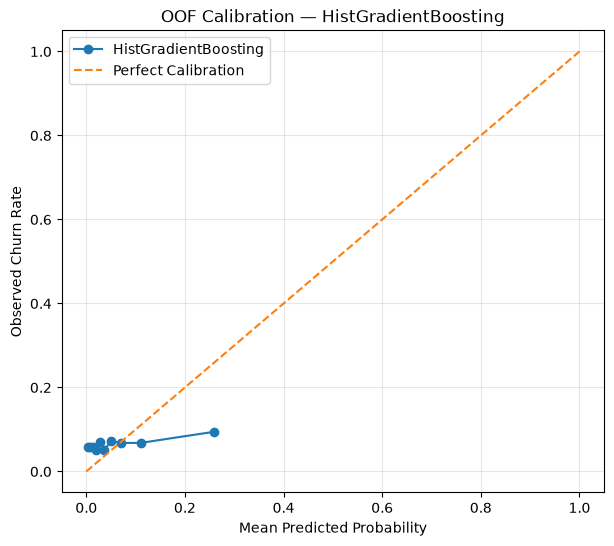

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.plot(
    hgb_calibration_table["Mean Predicted Probability"],
    hgb_calibration_table["Observed Churn Rate"],
    marker="o",
    label="HistGradientBoosting",
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration",
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Churn Rate")
plt.title("OOF Calibration — HistGradientBoosting")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

OOF calibration analysis shows that Logistic Regression has the lowest Brier score among the evaluated baseline models (0.0606), while Random Forest is substantially less calibrated (0.1794). HistGradientBoosting has a Brier score of 0.0660 but shows noticeable overprediction in its upper probability bins. Therefore, raw model probabilities should not yet be interpreted as calibrated churn probabilities.

In [72]:
candidate_model_evidence = final_model_comparison.copy()

candidate_model_evidence[
    [
        "Model",
        "CV PR-AUC",
        "CV ROC-AUC",
        "Threshold",
        "Test PR-AUC",
        "Test ROC-AUC",
        "Test F1",
        "Test Recall",
        "Test Precision",
        "Coverage",
    ]
]

,Model,CV PR-AUC,CV ROC-AUC,Threshold,Test PR-AUC,Test ROC-AUC,Test F1,Test Recall,Test Precision,Coverage
0,Logistic Regression,0.082645,0.567171,0.06,0.082143,0.559192,0.124473,0.536364,0.070406,0.495565
1,Random Forest,0.080668,0.561805,0.06,0.083352,0.566592,0.122154,1.000000,0.065050,1.000000
2,HistGradientBoosting,0.079645,0.538989,0.05,0.089013,0.592640,0.157687,0.545455,0.092166,0.384979
3,Logistic Regression Tuned,0.092323,NaN,0.06,0.079787,0.557789,0.129572,0.563636,0.073200,0.500887
4,Random Forest Tuned,0.095445,NaN,0.35,0.082791,0.563366,0.124466,0.927273,0.066710,0.904199
5,HistGradientBoosting Tuned,0.091899,NaN,0.05,0.087748,0.581634,0.137441,0.527273,0.079019,0.434063


In [73]:
candidate_model_evidence.sort_values(
    by=["Test PR-AUC", "Test ROC-AUC"],
    ascending=False,
)

,Model,CV PR-AUC,CV ROC-AUC,Threshold,Test PR-AUC,Test ROC-AUC,Test F1,Test Recall,Test Precision,Coverage
2,HistGradientBoosting,0.079645,0.538989,0.05,0.089013,0.592640,0.157687,0.545455,0.092166,0.384979
5,HistGradientBoosting Tuned,0.091899,NaN,0.05,0.087748,0.581634,0.137441,0.527273,0.079019,0.434063
1,Random Forest,0.080668,0.561805,0.06,0.083352,0.566592,0.122154,1.000000,0.065050,1.000000
4,Random Forest Tuned,0.095445,NaN,0.35,0.082791,0.563366,0.124466,0.927273,0.066710,0.904199
0,Logistic Regression,0.082645,0.567171,0.06,0.082143,0.559192,0.124473,0.536364,0.070406,0.495565
3,Logistic Regression Tuned,0.092323,NaN,0.06,0.079787,0.557789,0.129572,0.563636,0.073200,0.500887


In [74]:
calibration_comparison

,Model,Brier Score
0,Logistic Regression,0.060551
1,Random Forest,0.179356
2,HistGradientBoosting,0.065957


In [75]:
tuned_logistic_cv_result = evaluate_model_cv(
    model=logistic_search.best_estimator_,
    X=X_train,
    y=y_train,
)

tuned_random_forest_cv_result = evaluate_model_cv(
    model=random_forest_search.best_estimator_,
    X=X_train,
    y=y_train,
)

tuned_hgb_cv_result = evaluate_model_cv(
    model=hist_gradient_boosting_search.best_estimator_,
    X=X_train,
    y=y_train,
)

In [76]:
tuned_calibration_comparison = pd.DataFrame(
    [
        {
            "Model": "Logistic Regression Tuned",
            "Brier Score": evaluate_calibration(
                y_train,
                tuned_logistic_cv_result["oof_predictions"],
            )["brier_score"],
        },
        {
            "Model": "Random Forest Tuned",
            "Brier Score": evaluate_calibration(
                y_train,
                tuned_random_forest_cv_result["oof_predictions"],
            )["brier_score"],
        },
        {
            "Model": "HistGradientBoosting Tuned",
            "Brier Score": evaluate_calibration(
                y_train,
                tuned_hgb_cv_result["oof_predictions"],
            )["brier_score"],
        },
    ]
)

tuned_calibration_comparison

,Model,Brier Score
0,Logistic Regression Tuned,0.060465
1,Random Forest Tuned,0.212190
2,HistGradientBoosting Tuned,0.060758


In [77]:
all_calibration_comparison = pd.concat(
    [
        calibration_comparison,
        tuned_calibration_comparison,
    ],
    ignore_index=True,
)

all_calibration_comparison.sort_values(
    "Brier Score",
    ascending=True,
)

,Model,Brier Score
3,Logistic Regression Tuned,0.060465
0,Logistic Regression,0.060551
5,HistGradientBoosting Tuned,0.060758
2,HistGradientBoosting,0.065957
1,Random Forest,0.179356
4,Random Forest Tuned,0.212190


In [83]:
from importlib import reload

import src.modeling.calibration as calibration

reload(calibration)

<module 'src.modeling.calibration' from 'c:\\Users\\yashv\\OneDrive\\Desktop\\telecom-churn-platform\\src\\modeling\\calibration.py'>

In [84]:
from src.modeling.calibration import (
    build_calibrated_model,
    evaluate_calibration,
    create_calibration_table,
)

In [85]:
raw_hgb = hist_gradient_boosting_search.best_estimator_

sigmoid_hgb = build_calibrated_model(
    estimator=hist_gradient_boosting_search.best_estimator_,
    method="sigmoid",
    cv=5,
)

isotonic_hgb = build_calibrated_model(
    estimator=hist_gradient_boosting_search.best_estimator_,
    method="isotonic",
    cv=5,
)

In [86]:
raw_hgb_oof_proba = tuned_hgb_cv_result["oof_predictions"]

In [87]:
sigmoid_hgb_cv_result = evaluate_model_cv(
    model=sigmoid_hgb,
    X=X_train,
    y=y_train,
)

isotonic_hgb_cv_result = evaluate_model_cv(
    model=isotonic_hgb,
    X=X_train,
    y=y_train,
)

In [88]:
raw_hgb_calibration = evaluate_calibration(
    y_true=y_train,
    y_proba=raw_hgb_oof_proba,
)

sigmoid_hgb_calibration = evaluate_calibration(
    y_true=y_train,
    y_proba=sigmoid_hgb_cv_result["oof_predictions"],
)

isotonic_hgb_calibration = evaluate_calibration(
    y_true=y_train,
    y_proba=isotonic_hgb_cv_result["oof_predictions"],
)

In [89]:
hgb_calibration_comparison = pd.DataFrame(
    [
        {
            "Model": "HGB Raw",
            "Brier Score": raw_hgb_calibration["brier_score"],
            "PR-AUC": tuned_hgb_cv_result["metrics"]["PR-AUC"],
            "ROC-AUC": tuned_hgb_cv_result["metrics"]["ROC-AUC"],
        },
        {
            "Model": "HGB + Sigmoid",
            "Brier Score": sigmoid_hgb_calibration["brier_score"],
            "PR-AUC": sigmoid_hgb_cv_result["metrics"]["PR-AUC"],
            "ROC-AUC": sigmoid_hgb_cv_result["metrics"]["ROC-AUC"],
        },
        {
            "Model": "HGB + Isotonic",
            "Brier Score": isotonic_hgb_calibration["brier_score"],
            "PR-AUC": isotonic_hgb_cv_result["metrics"]["PR-AUC"],
            "ROC-AUC": isotonic_hgb_cv_result["metrics"]["ROC-AUC"],
        },
    ]
)

hgb_calibration_comparison

,Model,Brier Score,PR-AUC,ROC-AUC
0,HGB Raw,0.060758,0.087785,0.572051
1,HGB + Sigmoid,0.060521,0.085955,0.572283
2,HGB + Isotonic,0.060905,0.084515,0.567637


In [90]:
raw_hgb_calibration_table = create_calibration_table(
    y_train,
    raw_hgb_oof_proba,
)

sigmoid_hgb_calibration_table = create_calibration_table(
    y_train,
    sigmoid_hgb_cv_result["oof_predictions"],
)

isotonic_hgb_calibration_table = create_calibration_table(
    y_train,
    isotonic_hgb_cv_result["oof_predictions"],
)

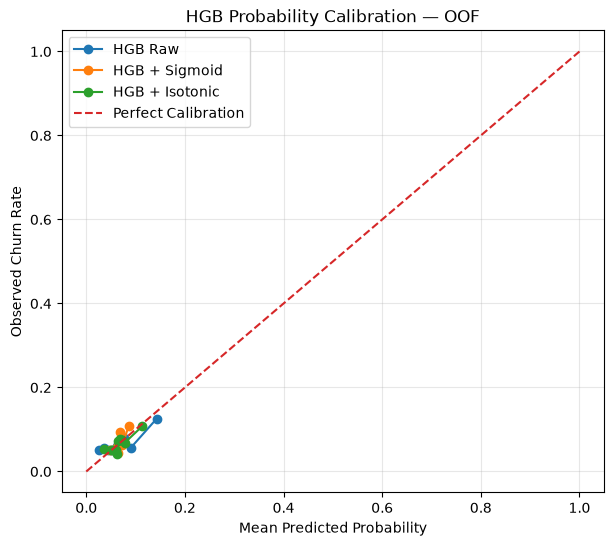

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.plot(
    raw_hgb_calibration_table["Mean Predicted Probability"],
    raw_hgb_calibration_table["Observed Churn Rate"],
    marker="o",
    label="HGB Raw",
)

plt.plot(
    sigmoid_hgb_calibration_table["Mean Predicted Probability"],
    sigmoid_hgb_calibration_table["Observed Churn Rate"],
    marker="o",
    label="HGB + Sigmoid",
)

plt.plot(
    isotonic_hgb_calibration_table["Mean Predicted Probability"],
    isotonic_hgb_calibration_table["Observed Churn Rate"],
    marker="o",
    label="HGB + Isotonic",
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration",
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Churn Rate")
plt.title("HGB Probability Calibration — OOF")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [92]:
final_calibrated_hgb = build_calibrated_model(
    estimator=hist_gradient_boosting_search.best_estimator_,
    method="sigmoid",
    cv=5,
)

final_calibrated_hgb.fit(
    X_train,
    y_train,
)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",Pipeline(step...m_state=42))])
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...001CC147DCEC0>, <sk

In [93]:
calibrated_hgb_test_proba = final_calibrated_hgb.predict_proba(
    X_test
)[:, 1]

In [94]:
final_calibrated_hgb_calibration = evaluate_calibration(
    y_true=y_test,
    y_proba=calibrated_hgb_test_proba,
)

final_calibrated_hgb_calibration["brier_score"]

0.06058130822371074

In [96]:
from src.modeling.evaluation import evaluate_test_predictions

In [97]:
final_calibrated_hgb_test_metrics = evaluate_test_predictions(
    y_true=y_test,
    y_proba=calibrated_hgb_test_proba,
    threshold=0.05,
)

final_calibrated_hgb_test_metrics

Threshold               0.050000
PR-AUC                  0.086978
ROC-AUC                 0.578495
Precision               0.067967
Recall                  0.981818
F1                      0.127134
Customers Flagged    1589.000000
Coverage                0.939681
dtype: float64